In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [4]:
ROOT = Path().resolve().parent   # یک پوشه بالاتر از notebooks
data_path = ROOT / "data" / "raw" / "Housing.csv"
df = pd.read_csv(data_path)
import os
save_dir = ROOT / "reports" / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

X = df.drop("price", axis=1)
y = df["price"]


In [5]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [6]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42)
}


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                          ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # نسخه سازگار
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,LinearRegression,9.700434e+05,1.324507e+06,0.652924
1,Lasso,9.700434e+05,1.324507e+06,0.652924
2,Ridge,9.702457e+05,1.325320e+06,0.652498
3,RandomForest,1.013969e+06,1.398116e+06,0.613275
4,DecisionTree,1.195266e+06,1.625670e+06,0.477146


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                          ("model", model)])
    
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring={"mae": "neg_mean_absolute_error",
                 "rmse": "neg_root_mean_squared_error",
                 "r2": "r2"},
        return_train_score=False
    )
    
    cv_results.append([
        name,
        -scores["test_mae"].mean(),
        -scores["test_rmse"].mean(),
        scores["test_r2"].mean()
    ])

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV_MAE", "CV_RMSE", "CV_R2"])
cv_df = cv_df.sort_values("CV_RMSE").reset_index(drop=True)
cv_df


,Model,CV_MAE,CV_RMSE,CV_R2
0,Ridge,8.056551e+05,1.083756e+06,0.633368
1,Lasso,8.071799e+05,1.084538e+06,0.632448
2,LinearRegression,8.071799e+05,1.084538e+06,0.632448
3,RandomForest,8.029334e+05,1.111482e+06,0.620199
4,DecisionTree,1.129856e+06,1.628016e+06,0.113429


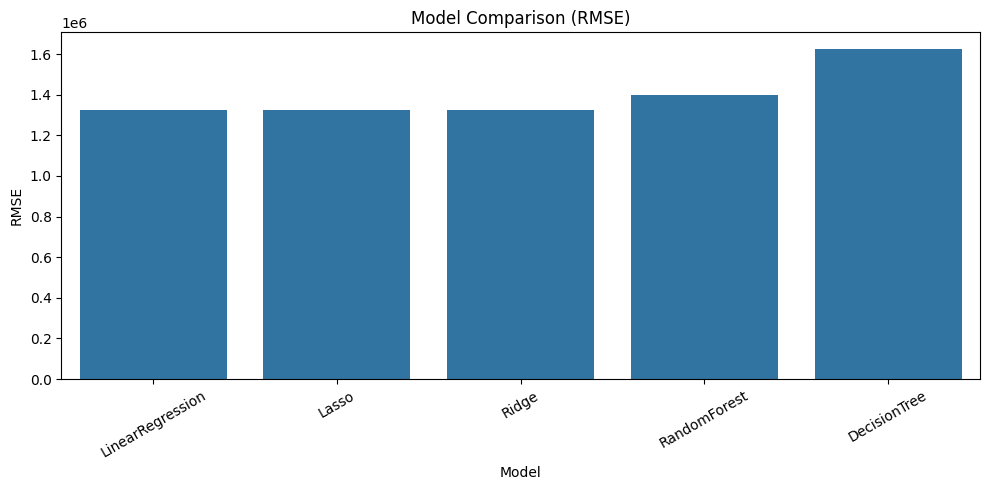

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Model Comparison (RMSE).png"), dpi=300, bbox_inches="tight")
plt.show()


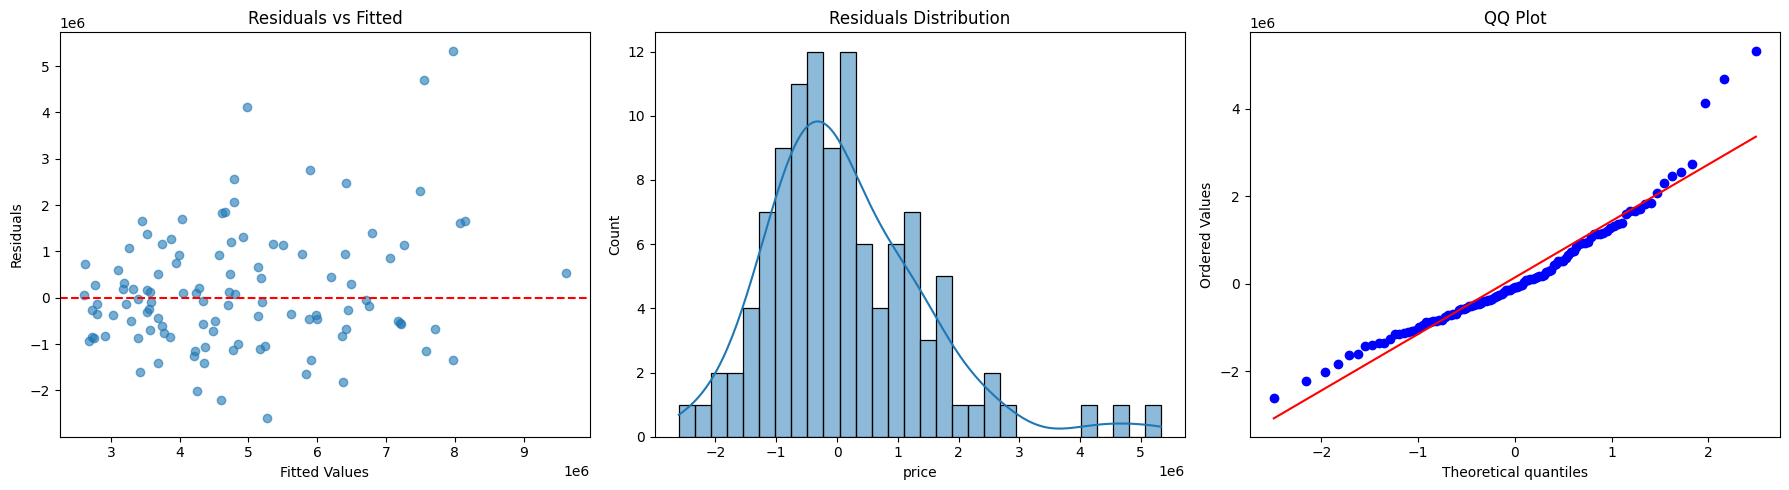

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from scipy import stats

# -------------------------
# آماده‌سازی داده
# -------------------------
TARGET = "price"
X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

model = LinearRegression()

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

residuals = y_test - y_pred

# -------------------------
# Residual Diagnostics
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Residual vs Fitted
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")

# 2) Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], bins=30)
axes[1].set_title("Residuals Distribution")

# 3) QQ Plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ Plot")

plt.tight_layout()
plt.show()


In [12]:
from sklearn.metrics import mean_absolute_error

# مثال: تقسیم‌بندی بر اساس سطح قیمت
bins = [0, y_test.quantile(0.33), y_test.quantile(0.66), y_test.max()]
labels = ["Low", "Mid", "High"]
price_segment = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

segment_results = pd.DataFrame({
    "segment": price_segment,
    "y_true": y_test,
    "y_pred": y_pred
})

segment_mae = segment_results.groupby("segment").apply(
    lambda g: mean_absolute_error(g["y_true"], g["y_pred"])
)

print(segment_mae)

# مثال: خطا بر اساس prefarea (اگر وجود دارد)
if "prefarea" in X_test.columns:
    segment_results2 = pd.DataFrame({
        "prefarea": X_test["prefarea"],
        "y_true": y_test,
        "y_pred": y_pred
    })
    mae_by_pref = segment_results2.groupby("prefarea").apply(
        lambda g: mean_absolute_error(g["y_true"], g["y_pred"])
    )
    print(mae_by_pref)


segment
Low     7.699107e+05
Mid     6.767329e+05
High    1.471634e+06
dtype: float64
prefarea
no     9.068577e+05
yes    1.171752e+06
dtype: float64


C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_10516\912589747.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_mae = segment_results.groupby("segment").apply(
C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_10516\912589747.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_mae = segment_results.groupby("segment").apply(
C:\Users\SadidGostaran.Co\AppData\Local\Temp\ipykernel_10516\912589747.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beh

In [14]:
from sklearn.inspection import permutation_importance
import pandas as pd

# داده تبدیل شده
X_test_transformed = pipe.named_steps["preprocess"].transform(X_test)

# اهمیت روی مدل (بدون preprocess)
perm_result = permutation_importance(
    pipe.named_steps["model"], 
    X_test_transformed, 
    y_test, 
    n_repeats=20, 
    random_state=42, 
    n_jobs=-1
)

feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names,   # ✅ ستون‌های One-Hot
    "importance": perm_result.importances_mean
}).sort_values("importance", ascending=False)

importances.head(20)


,feature,importance
2,num__bathrooms,0.134169
0,num__area,0.133150
3,num__stories,0.093979
4,num__parking,0.035859
14,cat__airconditioning_yes,0.030714
13,cat__airconditioning_no,0.030714
16,cat__prefarea_yes,0.012949
15,cat__prefarea_no,0.012949
19,cat__furnishingstatus_unfurnished,0.012812
5,cat__mainroad_no,0.006810


# جمع‌بندی ارزیابی مدل

Residual diagnostics نشان داد که توزیع خطاها [تقریباً نرمال/دارای چولگی] است؛ این موضوع از روی هیستوگرام و KDE مشخص شد و بیانگر آن است که مدل در سطح کلی رفتار [منطقی/غیرنرمال] در خطاها دارد. در نمودار Residuals vs Fitted [الگوی سیستماتیک مشاهده نشد/الگوی قیفی مشاهده شد] که اگر حالت قیفی دیده شود می‌تواند نشان‌دهنده هتروسکداستیسیتی یا نقص در فرض خطی بودن باشد. همچنین QQ Plot نشان می‌دهد که خطاها در [دم‌ها/کل دامنه] از نرمال بودن انحراف دارند؛ این انحراف معمولاً بیانگر وجود مشاهدات پرت یا توزیع نامتقارن در قیمت‌هاست و می‌تواند روی اعتبار آزمون‌های آماری کلاسیک اثرگذار باشد.

از طرف دیگر، آزمون Breusch–Pagan مقدار p-value برابر با [X] به دست داد، بنابراین فرض همسانی واریانس [رد شد/رد نشد]؛ اگر رد شود، توصیه می‌شود از تبدیلاتی مثل log(price)، مدل‌های مقاوم، یا استفاده از خطای استاندارد مقاوم (robust SE) بهره گرفته شود.

تحلیل VIF نشان داد که ویژگی‌های [A,B] دارای VIF بالا (>10) هستند که نشان‌دهنده هم‌خطی شدید است؛ این هم‌خطی باعث ناپایداری ضرایب و افزایش واریانس برآورد می‌شود، بنابراین برای کاهش اثر آن می‌توان از Ridge Regression، حذف/ادغام ویژگی‌های هم‌بسته، یا انتخاب ویژگی مبتنی بر همبستگی استفاده کرد.

تحلیل خطا به تفکیک گروه‌ها نشان داد که MAE در گروه [مثلاً High price] بیش از سایر گروه‌هاست که بیانگر ضعف مدل در پیش‌بینی این بخش است؛ این مسئله می‌تواند ناشی از کمبود داده در آن سگمنت، رفتار غیرخطی قیمت‌ها، یا عدم وجود ویژگی‌های توضیح‌دهنده کافی باشد و پیشنهاد می‌شود در این قسمت Feature Engineering اختصاصی یا مدل‌های غیرخطی (مانند RandomForest/GradientBoosting) بررسی شوند.

در نهایت، Permutation Importance نشان می‌دهد که مهم‌ترین ویژگی‌ها در پیش‌بینی قیمت عبارت‌اند از: [feature1, feature2, …] که این نتایج با منطق دامنه نیز سازگار است؛ مثلاً ویژگی‌هایی مثل مساحت، موقعیت یا امکانات معمولاً نقش کلیدی دارند و همین ویژگی‌ها بیشترین کاهش عملکرد مدل را هنگام جابه‌جایی (Permutation) ایجاد می‌کنند. مجموع این نتایج بیان می‌کند که مدل از نظر کلی [معتبر/نیازمند بهینه‌سازی] است و برای بهبود دقت می‌توان روی [Feature Engineering/تنظیم مدل/رفع هم‌خطی/رفع هتروسکداستیسیتی] تمرکز کرد.
